In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df=pd.read_csv("diabetes (1).csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.size

6912

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [9]:
(df==0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [10]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols] = df[cols].replace(0, np.nan)

In [11]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [12]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [13]:
df['Outcome'].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

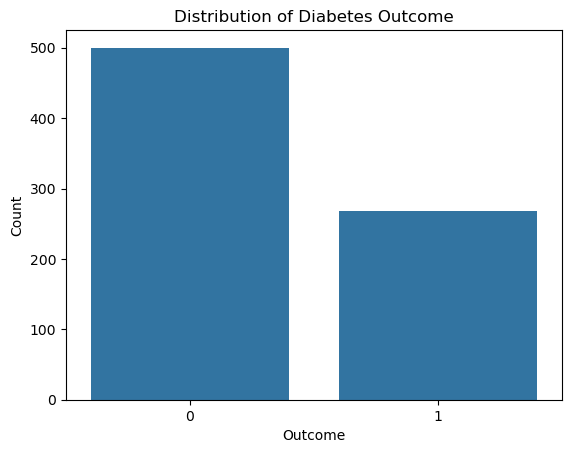

In [14]:
sns.countplot(x='Outcome', data=df)

plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

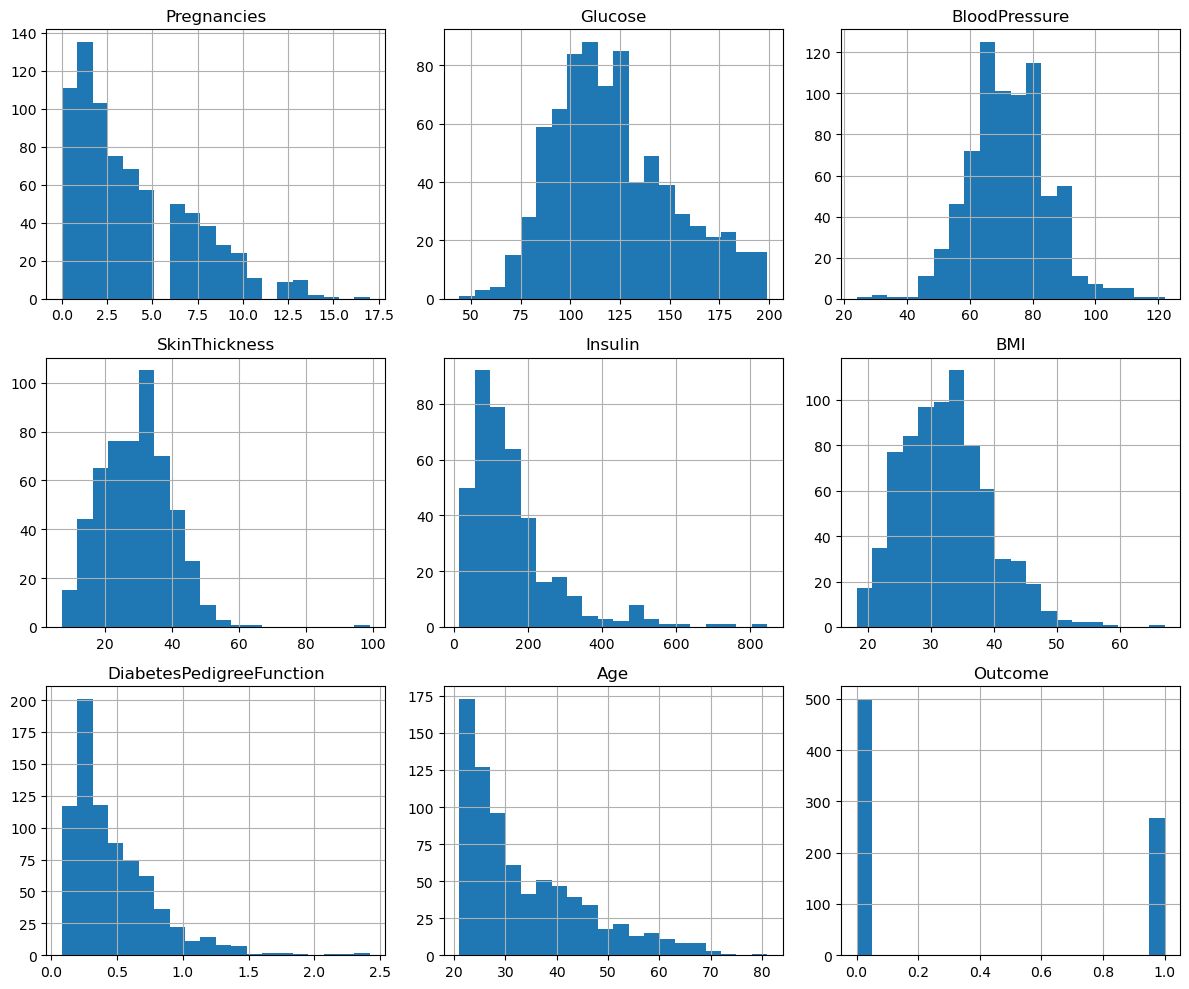

In [15]:
#Histogram
df.hist(figsize=(12, 10), bins=20)

plt.tight_layout()
plt.show()

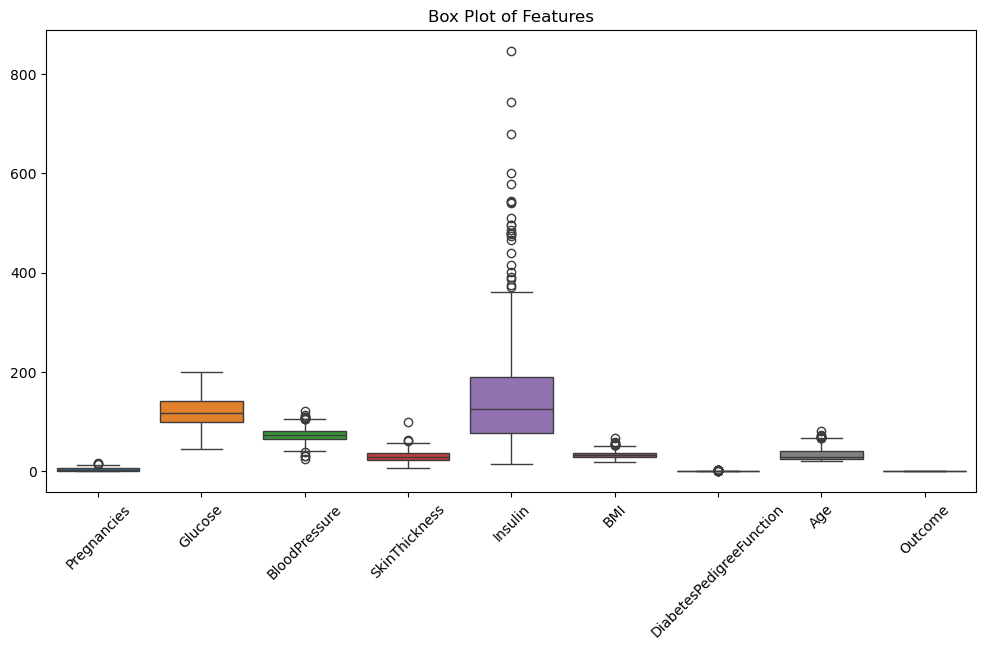

In [17]:
#Boxplot
plt.figure(figsize=(12, 6))

sns.boxplot(df)

plt.xticks(rotation=45)
plt.title('Box Plot of Features')
plt.show()

#We won't automatically delete them. A high glucose value, for example, could be a legitimate medical observation.

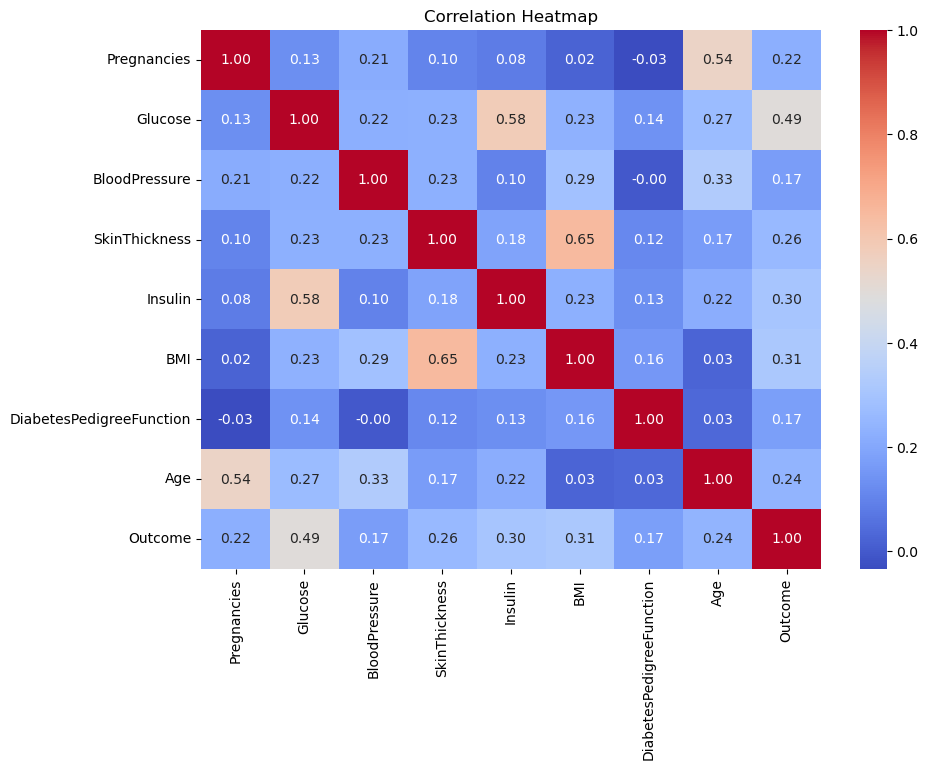

In [19]:
#Correlation Heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

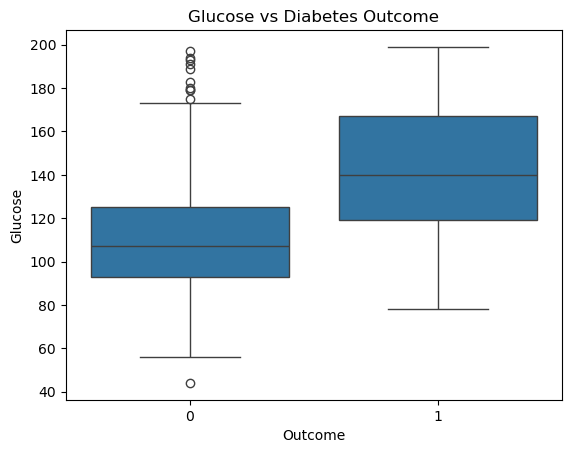

In [20]:
#Realtionship with outcome
sns.boxplot(x='Outcome', y='Glucose', data=df)

plt.title('Glucose vs Diabetes Outcome')
plt.show()

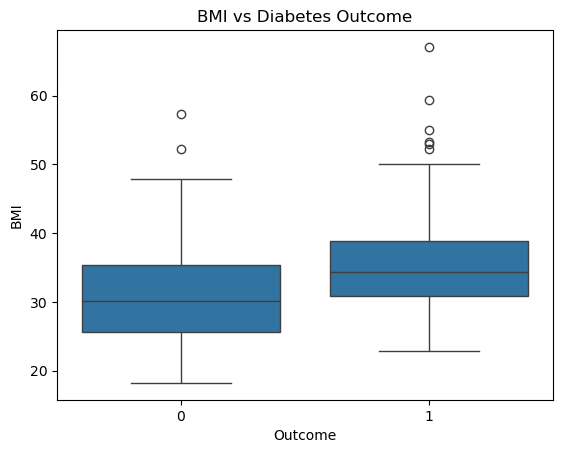

In [21]:
sns.boxplot(x='Outcome', y='BMI', data=df)

plt.title('BMI vs Diabetes Outcome')
plt.show()

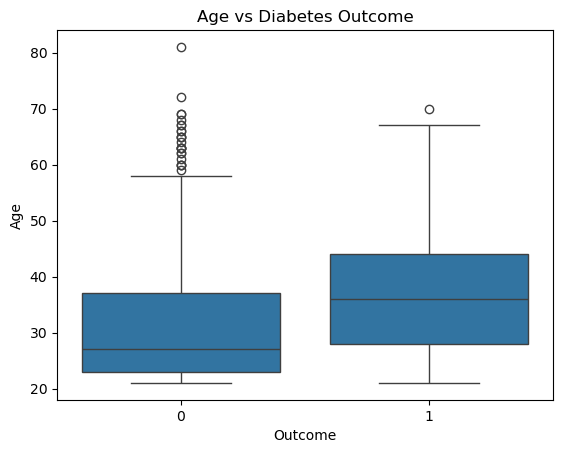

In [22]:
sns.boxplot(x='Outcome', y='Age', data=df)

plt.title('Age vs Diabetes Outcome')
plt.show()

"During EDA, I examined the distributions, outliers, class balance and correlations among the features. Glucose showed a relatively strong relationship with the diabetes outcome. Some variables contained zero values that are not physiologically meaningful, so I identified them for missing-value treatment. I also observed potential outliers, but I did not automatically remove them because extreme medical measurements can represent genuine observations."

In [25]:
#Data Preprocessing
X = df.drop('Outcome', axis=1)
y = df['Outcome']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (614, 8)
X_test: (154, 8)
y_train: (614,)
y_test: (154,)


In [30]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

C:\Users\areef\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


In [31]:
#Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
#Model Building
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [33]:
#Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.7077922077922078
Precision: 0.6
Recall   : 0.5
F1 Score : 0.5454545454545454
ROC-AUC  : 0.812962962962963


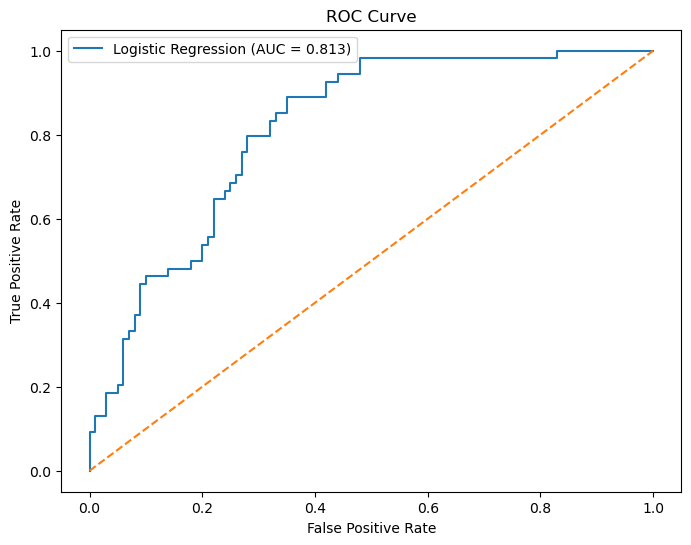

In [34]:
#ROC- Curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [35]:
#Interpretation of Logistic Regression coefficients.
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients

,Feature,Coefficient
0,Pregnancies,0.377446
1,Glucose,1.182567
2,BloodPressure,-0.044111
3,SkinThickness,0.028321
4,Insulin,-0.066119
5,BMI,0.688652
6,DiabetesPedigreeFunction,0.233337
7,Age,0.147794


In [36]:
coefficients['Absolute_Coefficient'] = coefficients['Coefficient'].abs()

coefficients.sort_values(
    'Absolute_Coefficient',
    ascending=False
)

,Feature,Coefficient,Absolute_Coefficient
1,Glucose,1.182567,1.182567
5,BMI,0.688652,0.688652
0,Pregnancies,0.377446,0.377446
6,DiabetesPedigreeFunction,0.233337,0.233337
7,Age,0.147794,0.147794
4,Insulin,-0.066119,0.066119
2,BloodPressure,-0.044111,0.044111
3,SkinThickness,0.028321,0.028321


In [37]:
coefficients['Odds_Ratio'] = np.exp(coefficients['Coefficient'])

coefficients.sort_values(
    'Odds_Ratio',
    ascending=False
)

,Feature,Coefficient,Absolute_Coefficient,Odds_Ratio
1,Glucose,1.182567,1.182567,3.262739
5,BMI,0.688652,0.688652,1.991030
0,Pregnancies,0.377446,0.377446,1.458554
6,DiabetesPedigreeFunction,0.233337,0.233337,1.262807
7,Age,0.147794,0.147794,1.159274
3,SkinThickness,0.028321,0.028321,1.028725
2,BloodPressure,-0.044111,0.044111,0.956848
4,Insulin,-0.066119,0.066119,0.936019



Holding the other features constant, a one-standard-deviation increase in Glucose is associated with approximately 3.26 times the odds of the model predicting diabetes.

In [38]:
import joblib

joblib.dump(model, "diabetes_logistic_model.pkl")
joblib.dump(imputer, "diabetes_imputer.pkl")
joblib.dump(scaler, "diabetes_scaler.pkl")

['diabetes_scaler.pkl']

In [39]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'adult_with_headers (1).csv', 'anime.csv', 'ANN.ipynb', 'app.py', 'Basic python.ipynb', 'Basic stats-2.ipynb', 'Basic stats1.ipynb', 'Billing_Data.csv', 'Cardiotocographic.csv', 'Clustering.ipynb', 'Confidence Intervel.ipynb', 'Data Structures & Control Structures.ipynb', 'Data Transformation.ipynb', 'Decision Tree.ipynb', 'diabetes (1).csv', 'diabetes_imputer.pkl', 'diabetes_logistic_model.pkl', 'diabetes_scaler.pkl', 'Drug Response Classification.ipynb', 'EastWestAirlines.xlsx', 'EDA.ipynb', 'exchange_rate.csv', 'glass.xlsx', 'heart_disease.xlsx', 'Hypothesis Testing.ipynb', 'LGBM & XGBM.ipynb', 'Logistic Regression.ipynb', 'MLR.ipynb', 'Patient_Data.csv', 'PCA.ipynb', 'Personal Logistic regression.ipynb', 'Pharma_Industry.csv', 'Random Forest.ipynb', 'Recommendation System.ipynb', 'sales_data_with_discounts.csv', 'sonardataset.csv', 'SVM.ipynb', 'Time series.ipynb', 'ToyotaCorolla - MLR.csv', 'wine.csv']


1. Difference between Precision and Recall?

Precision Measures how many predicted positive cases are actually positive.Recall Measures how many actual positive cases are correctly identified.Precision focuses on minimizing false positives, while recall focuses on minimizing false negatives. In medical diagnosis, recall is often prioritized to avoid missing patients who have the disease.

2. What is Cross-Validation  and why is it important in binary classification?

Cross-validation is a technique used to evaluate a machine learning model by dividing the dataset into multiple folds. The model is trained on some folds and tested on the remaining fold. This process is repeated several times, and the average performance is used to estimate how well the model generalizes to unseen data.
Because It Produces a more reliable performance estimate. And alsoReduces the risk of overfitting.It Makes efficient use of available data.Commonly uses 5-fold or 10-fold cross-validation.